# 01. JEPX 東京エリア価格 - 前処理

JEPX スポット市場の東京エリアプライス（30分粒度・48コマ/日）を目的変数とした day-ahead 予測のための学習データを構築する。

**予測タスク**: 当日までの確定データから翌日 24 時間 (48 コマ) を一括予測する day-ahead 予測。  
したがって対象日 `D` の特徴量は **日付が `D-1` 以前のデータからのみ** 作る (同日リーク禁止)。

## データソース
- **JEPX スポット価格**: `https://www.jepx.jp/market/excel/spot_{year}.csv`
- **気象データ**: Open-Meteo Archive API (東京: lat=35.6895, lon=139.6917)
- **TEPCO エリア需給**: `area-{year}.csv` (旧, 〜2024-01) / `eria_jukyu_{YYYYMM}_03.csv` (新, 2024-02〜)

## 生成する特徴量
- カレンダー: hour, minute, dayofweek, month, is_weekend, is_holiday, is_dayoff
- 気象: temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m, shortwave_radiation
- **TEPCO 需給** (MW): tepco_demand, tepco_solar, tepco_wind, **net_demand** (= 需要 − PV − 風力), pv_ratio
- ラグ: 前日同スロット, 前週同スロット (どちらも `D-1` 以前)
- 日次集約: 前日 / 前週同曜日の mean / max / min / std を全 48 スロットにブロードキャスト
- **目的変数バリアント** (分析用): target_log1p, target_arsinh, target_diff_1d/7d, target_dev_prev_day/week
- **トレンド参照**: trend_30d_mean (D-1 以前 30 日の日次平均)

## 出力 (すべて `data/` 配下に parquet で保存)
- `jepx_clean.parquet` … 整形後 JEPX (全エリア価格・出来高を含む 30分粒度時系列)
- `weather_tokyo_30min.parquet` … 30分粒度にアップサンプルした気象データ
- `tepco_supply_30min.parquet` … 30分粒度にアップサンプルした TEPCO 需給データ
- `jepx_tokyo_features.parquet` … 学習用最終特徴量 (target + カレンダー + 気象 + TEPCO + ラグ + ターゲット変換 + トレンド)
- `feature_metadata.json` … 列メタ情報

## 必要パッケージ
```
pip install requests jpholiday pyarrow pandas numpy matplotlib seaborn
```


## ライブラリ


In [18]:
from __future__ import annotations

import json
import time
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import requests
import jpholiday
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  matplotlib の日本語フォントを有効化
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid", font="IPAexGothic")


## パラメータ / パス


In [19]:
BASE_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "blog" / "06.JEPX_estimation",
    Path("/home/kohei/WorkSpace/blog/06.JEPX_estimation"),
]
BASE_DIR = next((p for p in BASE_DIR_CANDIDATES if (p / "data").exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("data/ ディレクトリが見つかりません。実行ディレクトリを確認してください。")

DATA_DIR = BASE_DIR / "data"
RAW_JEPX_DIR    = DATA_DIR / "raw_jepx"
RAW_WEATHER_DIR = DATA_DIR / "raw_weather"
RAW_TEPCO_DIR   = DATA_DIR / "raw_tepco"
for d in (RAW_JEPX_DIR, RAW_WEATHER_DIR, RAW_TEPCO_DIR):
    d.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2020, date.today().year + 1))

TOKYO_LAT, TOKYO_LON = 35.6895, 139.6917
TIMEZONE = "Asia/Tokyo"

JEPX_URL_FMT = "https://www.jepx.jp/market/excel/spot_{year}.csv"
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"
WEATHER_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "shortwave_radiation",
]

# TEPCO エリア需給データ
# - 〜2024-01: 年度別 1時間粒度 (cp932)
# - 2024-02〜: 月次 30分粒度 (utf-8)
TEPCO_ANNUAL_URL_FMT  = "https://www.tepco.co.jp/forecast/html/images/area-{year}.csv"
TEPCO_MONTHLY_URL_FMT = "https://www.tepco.co.jp/forecast/html/images/eria_jukyu_{yyyymm}_03.csv"
TEPCO_ANNUAL_FISCAL_YEARS = list(range(2020, 2024))           # FY2020-2023 = 2020-04 〜 2024-01
TEPCO_MONTHLY_START = date(2024, 2, 1)                        # 2024-02 から月次

TARGET_COL = "area_price_tokyo"

# 出力 parquet (すべて data/ 配下)
JEPX_CLEAN_PARQUET    = DATA_DIR / "jepx_clean.parquet"           # 整形後 JEPX
WEATHER_30MIN_PARQUET = DATA_DIR / "weather_tokyo_30min.parquet"  # 気象 30分粒度
TEPCO_30MIN_PARQUET   = DATA_DIR / "tepco_supply_30min.parquet"   # TEPCO 需給 30分粒度
OUTPUT_PARQUET        = DATA_DIR / "jepx_tokyo_features.parquet"  # 学習用最終特徴量
FEATURE_META_JSON     = DATA_DIR / "feature_metadata.json"

print("BASE_DIR :", BASE_DIR)
print("YEARS    :", YEARS)


BASE_DIR : /home/kohei/WorkSpace/blog/06.JEPX_estimation
YEARS    : [2020, 2021, 2022, 2023, 2024, 2025, 2026]


## JEPX データのダウンロード

年ごとに CSV をローカルキャッシュする。再実行時はスキップ。


In [20]:
def download_jepx_csv(year: int, out_dir: Path, *, force: bool = False) -> Path:
    """年単位でJEPXスポットCSVを取得しキャッシュする。"""
    out_path = out_dir / f"spot_{year}.csv"
    if out_path.exists() and not force:
        return out_path
    url = JEPX_URL_FMT.format(year=year)
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    out_path.write_bytes(resp.content)
    time.sleep(0.5)
    return out_path


jepx_paths = []
for year in YEARS:
    try:
        p = download_jepx_csv(year, RAW_JEPX_DIR)
        jepx_paths.append(p)
        print(f"[ok] {p.name}  size={p.stat().st_size:,}B")
    except Exception as e:
        print(f"[skip] {year}: {e}")


[ok] spot_2020.csv  size=3,060,830B
[ok] spot_2021.csv  size=4,751,940B
[ok] spot_2022.csv  size=4,647,331B
[ok] spot_2023.csv  size=4,476,034B
[ok] spot_2024.csv  size=4,536,270B
[ok] spot_2025.csv  size=4,462,994B
[ok] spot_2026.csv  size=673,708B


## JEPX データの読み込み・整形

- 全年分を結合し、日本語列を英字スネークケースへ。
- 時刻コード (1〜48) → スロット開始時刻 `(code-1) * 30 min` で datetime を組み立てる。


In [21]:
def _read_jepx_csv(path: Path) -> pd.DataFrame:
    for enc in ("cp932", "utf-8-sig", "utf-8"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("cp932/utf-8", b"", 0, 1, f"Failed to decode {path}")


# 列名は年によって微妙に揺れるため、部分一致で堅牢にマッピングする。
# 実カラム例 (2020 以降): 「年月日, 時刻コード, 売り入札量(kWh), ..., エリアプライス東京(円/kWh), ...」
JEPX_COLUMN_PATTERNS: dict[str, list[str]] = {
    "delivery_date":    ["年月日", "受渡日"],
    "slot_code":        ["時刻コード"],
    "sell_volume_kwh":  ["売り入札量"],
    "buy_volume_kwh":   ["買い入札量"],
    "trade_volume_kwh": ["約定総量"],
    "system_price":     ["システムプライス"],
    "area_price_hokkaido": ["エリアプライス北海道"],
    "area_price_tohoku":   ["エリアプライス東北"],
    "area_price_tokyo":    ["エリアプライス東京"],
    "area_price_chubu":    ["エリアプライス中部"],
    "area_price_hokuriku": ["エリアプライス北陸"],
    "area_price_kansai":   ["エリアプライス関西"],
    "area_price_chugoku":  ["エリアプライス中国"],
    "area_price_shikoku":  ["エリアプライス四国"],
    "area_price_kyushu":   ["エリアプライス九州"],
}


def _resolve_columns(df_columns: list[str]) -> dict[str, str]:
    mapping = {}
    for new_name, patterns in JEPX_COLUMN_PATTERNS.items():
        for col in df_columns:
            if any(pat in col for pat in patterns):
                mapping[col] = new_name
                break
    return mapping


def load_jepx(paths: list[Path]) -> pd.DataFrame:
    frames = []
    for path in paths:
        raw = _read_jepx_csv(path)
        rename_map = _resolve_columns(list(raw.columns))
        missing = set(JEPX_COLUMN_PATTERNS) - set(rename_map.values())
        if missing:
            print(f"[warn] {path.name}: 未解決の列 {sorted(missing)}")
        df = raw.rename(columns=rename_map)[list(rename_map.values())].copy()
        frames.append(df)
    df_all = pd.concat(frames, ignore_index=True)

    df_all["delivery_date"] = pd.to_datetime(df_all["delivery_date"], errors="coerce")
    df_all["slot_code"] = pd.to_numeric(df_all["slot_code"], errors="coerce").astype("Int64")

    num_cols = [c for c in df_all.columns if c not in ("delivery_date", "slot_code")]
    df_all[num_cols] = df_all[num_cols].apply(pd.to_numeric, errors="coerce")

    # datetime = delivery_date + (slot_code - 1) * 30min  (スロット開始時刻)
    df_all = df_all.dropna(subset=["delivery_date", "slot_code"]).copy()
    df_all["datetime"] = df_all["delivery_date"] + pd.to_timedelta(
        (df_all["slot_code"].astype(int) - 1) * 30, unit="m"
    )
    df_all = df_all.sort_values("datetime").drop_duplicates("datetime").set_index("datetime")
    return df_all


jepx_df = load_jepx(jepx_paths)
print("jepx_df shape:", jepx_df.shape)
print("period      :", jepx_df.index.min(), "->", jepx_df.index.max())
display(jepx_df.head())


jepx_df shape: (107808, 15)
period      : 2020-04-01 00:00:00 -> 2026-05-25 23:30:00


,delivery_date,slot_code,sell_volume_kwh,buy_volume_kwh,trade_volume_kwh,system_price,area_price_hokkaido,area_price_tohoku,area_price_tokyo,area_price_chubu,area_price_hokuriku,area_price_kansai,area_price_chugoku,area_price_shikoku,area_price_kyushu
datetime,,,,,,,,,,,,,,,
2020-04-01 00:00:00,2020-04-01,1,16592450,18033600,15772950,6.43,6.84,6.76,6.76,4.00,4.00,4.00,4.00,4.00,4.00
2020-04-01 00:30:00,2020-04-01,2,16986950,18180600,15766550,5.77,6.62,6.62,6.62,3.73,3.73,3.73,3.73,3.73,3.73
2020-04-01 01:00:00,2020-04-01,3,17263950,18234450,15990350,5.18,6.61,6.61,6.61,4.09,4.09,4.09,4.09,4.09,4.09
2020-04-01 01:30:00,2020-04-01,4,17583250,18565050,16078100,4.87,6.51,6.51,6.51,4.04,4.04,4.04,4.04,4.04,4.04
2020-04-01 02:00:00,2020-04-01,5,17943550,18738950,16338200,4.87,6.51,6.51,6.51,4.09,4.09,4.09,4.09,4.09,4.09


In [22]:
# 連続性チェック (30分間隔・重複なし)
diffs = jepx_df.index.to_series().diff().value_counts().head()
print("index diffs:\n", diffs)
print("monotonic   :", jepx_df.index.is_monotonic_increasing)
print("duplicated  :", jepx_df.index.duplicated().sum())
print("NaN target  :", jepx_df[TARGET_COL].isna().sum())

# 整形後 JEPX を parquet に保存
jepx_df.to_parquet(JEPX_CLEAN_PARQUET)
print("saved       :", JEPX_CLEAN_PARQUET)


index diffs:
 datetime
0 days 00:30:00    107807
Name: count, dtype: int64
monotonic   : True
duplicated  : 0
NaN target  : 0
saved       : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/jepx_clean.parquet


## 気象データの取得 (Open-Meteo Archive)

年ごとにリクエストして JSON をキャッシュする。


In [23]:
def download_weather_json(year: int, out_dir: Path, *, force: bool = False) -> Path:
    out_path = out_dir / f"tokyo_{year}.json"
    if out_path.exists() and not force:
        return out_path

    start = f"{year}-01-01"
    end_real = min(date(year, 12, 31), date.today() - timedelta(days=1))
    end = end_real.isoformat()

    params = {
        "latitude": TOKYO_LAT,
        "longitude": TOKYO_LON,
        "start_date": start,
        "end_date": end,
        "hourly": ",".join(WEATHER_VARS),
        "timezone": TIMEZONE,
    }
    resp = requests.get(WEATHER_URL, params=params, timeout=60)
    resp.raise_for_status()
    out_path.write_text(resp.text, encoding="utf-8")
    time.sleep(0.5)
    return out_path


weather_paths = []
for year in YEARS:
    try:
        p = download_weather_json(year, RAW_WEATHER_DIR)
        weather_paths.append(p)
        print(f"[ok] {p.name}")
    except Exception as e:
        print(f"[skip] {year}: {e}")


[ok] tokyo_2020.json
[ok] tokyo_2021.json
[ok] tokyo_2022.json
[ok] tokyo_2023.json
[ok] tokyo_2024.json
[ok] tokyo_2025.json
[ok] tokyo_2026.json


## 気象データの読み込み・30分粒度へのアップサンプル

- 連続変数 (気温・湿度・風速・日射) は時間補間。
- `precipitation` は積算量で補間が不自然になるため `ffill` で 30 分粒度に伸ばす (1 時間分の降水量を 30 分 × 2 にコピー)。
- **前提**: 学習データは過去 archive を使うが、運用時の翌日気象は予報値で代替する。day-ahead 予測時点で翌日予報は既知なのでリークにはあたらない。


In [24]:
def load_weather(paths: list[Path]) -> pd.DataFrame:
    frames = []
    for path in paths:
        payload = json.loads(path.read_text(encoding="utf-8"))
        hourly = payload["hourly"]
        df = pd.DataFrame(hourly)
        df["datetime"] = pd.to_datetime(df["time"])  # tz-naive, Asia/Tokyo wall clock
        df = df.drop(columns=["time"]).set_index("datetime")
        frames.append(df)
    out = pd.concat(frames).sort_index()
    return out[~out.index.duplicated()]


weather_hourly = load_weather(weather_paths)
print("weather hourly shape:", weather_hourly.shape)
display(weather_hourly.head())


weather hourly shape: (56064, 5)


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation
datetime,,,,,
2020-01-01 00:00:00,1.2,58,0.0,41.4,0.0
2020-01-01 01:00:00,1.4,56,0.0,39.7,0.0
2020-01-01 02:00:00,1.5,56,0.0,33.0,0.0
2020-01-01 03:00:00,1.7,57,0.0,27.6,0.0
2020-01-01 04:00:00,1.9,58,0.0,25.6,0.0


In [25]:
def resample_weather_30min(weather_hourly: pd.DataFrame, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    interp_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "shortwave_radiation"]
    sum_cols = ["precipitation"]

    interp_30 = (
        weather_hourly[interp_cols]
        .resample("30min")
        .interpolate(method="time")
    )
    ffill_30 = (
        weather_hourly[sum_cols]
        .resample("30min")
        .ffill()
    )
    weather_30 = pd.concat([interp_30, ffill_30], axis=1).reindex(target_index)

    # Open-Meteo archive は今日-1 で打ち切るため、JEPX 側がより新しい場合に末尾が NaN になる。
    # 連続変数は ffill+bfill、降水量は欠損 = 0 mm として埋める (短い区間のみ想定)。
    pre_nan = weather_30.isna().sum()
    weather_30[interp_cols] = weather_30[interp_cols].ffill().bfill()
    weather_30[sum_cols] = weather_30[sum_cols].fillna(0.0)
    if pre_nan.sum() > 0:
        print("filled NaN per col:")
        print(pre_nan[pre_nan > 0])
    return weather_30


weather_30 = resample_weather_30min(weather_hourly, jepx_df.index)
print("weather_30 shape:", weather_30.shape)
print("NaN summary:\n", weather_30.isna().sum())
display(weather_30.head(6))

# 30分粒度の気象データを parquet に保存
weather_30.to_parquet(WEATHER_30MIN_PARQUET)
print("saved           :", WEATHER_30MIN_PARQUET)


filled NaN per col:
temperature_2m          49
relative_humidity_2m    49
wind_speed_10m          49
shortwave_radiation     49
precipitation           49
dtype: int64
weather_30 shape: (107808, 5)
NaN summary:
 temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
shortwave_radiation     0
precipitation           0
dtype: int64


,temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation,precipitation
datetime,,,,,
2020-04-01 00:00:00,9.1,91.0,13.30,0.0,0.0
2020-04-01 00:30:00,9.0,91.5,13.15,0.0,0.0
2020-04-01 01:00:00,8.9,92.0,13.00,0.0,0.0
2020-04-01 01:30:00,8.8,92.5,13.80,0.0,0.0
2020-04-01 02:00:00,8.7,93.0,14.60,0.0,0.0
2020-04-01 02:30:00,8.8,93.0,14.70,0.0,0.0


saved           : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/weather_tokyo_30min.parquet


## TEPCO エリア需給データの取得

東京エリアの **需要・太陽光発電量・風力発電量** を TEPCO 公開データから取得。  
産業実務で「価格の山谷を当てるなら **純需要 = 需要 − PV − 風力** が最重要特徴量」と複数の文献 (Hirota et al. 2024 等) で報告されている。

- **〜2024-01**: 年度別 1 時間粒度 (cp932)
- **2024-02〜**: 月次 30 分粒度 (utf-8)

**リーク観点**: 実績値は気象 archive と同じ扱い。同時刻 t の `demand(t)` / `solar(t)` を JEPX 価格(t) の外生変数として使う。day-ahead 推論時には TEPCO「でんき予報」翌日予測で代替する想定 (本ノートブックでは学習データに専念)。


In [26]:
def download_tepco_annual(fiscal_year: int, out_dir: Path, *, force: bool = False) -> Path | None:
    """年度別 1時間粒度ファイル (旧フォーマット) を取得。404 のときは None。"""
    out_path = out_dir / f"area-{fiscal_year}.csv"
    if out_path.exists() and not force and out_path.stat().st_size > 1000:
        return out_path
    url = TEPCO_ANNUAL_URL_FMT.format(year=fiscal_year)
    resp = requests.get(url, timeout=60)
    if resp.status_code != 200 or len(resp.content) < 1000:
        return None
    out_path.write_bytes(resp.content)
    time.sleep(0.5)
    return out_path


def download_tepco_monthly(yyyymm: str, out_dir: Path, *, force: bool = False) -> Path | None:
    """月次 30分粒度ファイル (新フォーマット) を取得。404/未公開のときは None。"""
    out_path = out_dir / f"eria_jukyu_{yyyymm}_03.csv"
    if out_path.exists() and not force and out_path.stat().st_size > 1000:
        return out_path
    url = TEPCO_MONTHLY_URL_FMT.format(yyyymm=yyyymm)
    resp = requests.get(url, timeout=60)
    if resp.status_code != 200 or len(resp.content) < 1000:
        return None
    out_path.write_bytes(resp.content)
    time.sleep(0.5)
    return out_path


def _next_month(d: date) -> date:
    return date(d.year + 1, 1, 1) if d.month == 12 else date(d.year, d.month + 1, 1)


# 旧フォーマット (年度別)
tepco_annual_paths: list[Path] = []
for fy in TEPCO_ANNUAL_FISCAL_YEARS:
    p = download_tepco_annual(fy, RAW_TEPCO_DIR)
    if p:
        tepco_annual_paths.append(p)
        print(f"[ok annual ] {p.name}  size={p.stat().st_size:,}B")
    else:
        print(f"[skip annual ] FY{fy}")

# 新フォーマット (月次): 2024-02 から今月まで
tepco_monthly_paths: list[Path] = []
cur = TEPCO_MONTHLY_START
today = date.today()
while cur <= today:
    yyyymm = cur.strftime("%Y%m")
    p = download_tepco_monthly(yyyymm, RAW_TEPCO_DIR)
    if p:
        tepco_monthly_paths.append(p)
        print(f"[ok monthly] {p.name}  size={p.stat().st_size:,}B")
    else:
        print(f"[skip monthly] {yyyymm}")
    cur = _next_month(cur)


[ok annual ] area-2020.csv  size=518,056B
[ok annual ] area-2021.csv  size=519,919B
[ok annual ] area-2022.csv  size=515,996B
[ok annual ] area-2023.csv  size=434,359B
[ok monthly] eria_jukyu_202402_03.csv  size=119,968B
[ok monthly] eria_jukyu_202403_03.csv  size=127,023B
[ok monthly] eria_jukyu_202404_03.csv  size=121,877B
[ok monthly] eria_jukyu_202405_03.csv  size=127,341B
[ok monthly] eria_jukyu_202406_03.csv  size=123,626B
[ok monthly] eria_jukyu_202407_03.csv  size=129,583B
[ok monthly] eria_jukyu_202408_03.csv  size=128,762B
[ok monthly] eria_jukyu_202409_03.csv  size=124,569B
[ok monthly] eria_jukyu_202410_03.csv  size=129,827B
[ok monthly] eria_jukyu_202411_03.csv  size=124,882B
[ok monthly] eria_jukyu_202412_03.csv  size=129,642B
[ok monthly] eria_jukyu_202501_03.csv  size=128,207B
[ok monthly] eria_jukyu_202502_03.csv  size=116,474B
[ok monthly] eria_jukyu_202503_03.csv  size=128,032B
[ok monthly] eria_jukyu_202504_03.csv  size=123,633B
[ok monthly] eria_jukyu_202505_03.csv

## TEPCO 需給データの読み込み・30分粒度化

旧フォーマットは 1 時間粒度 (単位: 万kWh = 10 MWh/h)、新フォーマットは 30 分粒度 (単位: MW平均)。  
両方を **MW** 単位に揃えて結合し、30 分グリッドへ resample してから JEPX インデックスに reindex する。  

抽出列: `tepco_demand` / `tepco_solar` / `tepco_wind`、派生で `net_demand = demand - solar - wind`、`pv_ratio = solar / demand`。


In [27]:
# 旧フォーマット (年度別 1h, 万kWh): ヘッダが 3 行ある (単位 / 大見出し / 小見出し)
TEPCO_OLD_COLUMNS = [
    "DATE", "TIME", "demand_man_kwh",
    "nuclear", "thermal", "hydro", "geothermal", "biomass",
    "solar_actual_man_kwh", "solar_curtail",
    "wind_actual_man_kwh", "wind_curtail",
    "pumped", "interconnect", "total",
]

# 新フォーマット (月次 30min, MW): ヘッダ 2 行
TEPCO_NEW_COLUMNS = [
    "DATE", "TIME", "tepco_demand",
    "nuclear", "thermal_lng", "thermal_coal", "thermal_oil", "thermal_other",
    "hydro", "geothermal", "biomass",
    "tepco_solar", "solar_curtail",
    "tepco_wind", "wind_curtail",
    "pumped", "battery", "interconnect", "other", "total",
]


def _parse_tepco_csv(path: Path, *, encoding: str, skiprows: int, columns: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, encoding=encoding, skiprows=skiprows, names=columns, header=None)
    df["datetime"] = pd.to_datetime(df["DATE"] + " " + df["TIME"], errors="coerce")
    return df.dropna(subset=["datetime"]).set_index("datetime")


def load_tepco_annual(paths: list[Path]) -> pd.DataFrame:
    """旧フォーマットを MW 単位の DataFrame として返す。"""
    frames = []
    for path in paths:
        df = _parse_tepco_csv(path, encoding="cp932", skiprows=3, columns=TEPCO_OLD_COLUMNS)
        # 万kWh (= 10 MWh/h、つまり 10 MW 平均) → MW
        out = pd.DataFrame(index=df.index)
        out["tepco_demand"] = pd.to_numeric(df["demand_man_kwh"], errors="coerce") * 10
        out["tepco_solar"]  = pd.to_numeric(df["solar_actual_man_kwh"], errors="coerce") * 10
        out["tepco_wind"]   = pd.to_numeric(df["wind_actual_man_kwh"],  errors="coerce") * 10
        frames.append(out)
    return pd.concat(frames).sort_index() if frames else pd.DataFrame()


def load_tepco_monthly(paths: list[Path]) -> pd.DataFrame:
    """新フォーマットは MW 平均なのでそのまま。"""
    frames = []
    for path in paths:
        df = _parse_tepco_csv(path, encoding="utf-8", skiprows=2, columns=TEPCO_NEW_COLUMNS)
        out = df[["tepco_demand", "tepco_solar", "tepco_wind"]].apply(pd.to_numeric, errors="coerce")
        frames.append(out)
    return pd.concat(frames).sort_index() if frames else pd.DataFrame()


tepco_annual = load_tepco_annual(tepco_annual_paths)
tepco_monthly = load_tepco_monthly(tepco_monthly_paths)
print(f"annual  : {tepco_annual.shape}  {tepco_annual.index.min() if len(tepco_annual) else '-'} -> {tepco_annual.index.max() if len(tepco_annual) else '-'}")
print(f"monthly : {tepco_monthly.shape} {tepco_monthly.index.min() if len(tepco_monthly) else '-'} -> {tepco_monthly.index.max() if len(tepco_monthly) else '-'}")

tepco_raw = pd.concat([tepco_annual, tepco_monthly]).sort_index()
tepco_raw = tepco_raw[~tepco_raw.index.duplicated(keep="last")]
print(f"combined: {tepco_raw.shape}  {tepco_raw.index.min()} -> {tepco_raw.index.max()}")
display(tepco_raw.head(3))
display(tepco_raw.tail(3))


annual  : (33624, 3)  2020-04-01 00:00:00 -> 2024-01-31 23:00:00
monthly : (40519, 3) 2024-02-01 00:00:00 -> 2026-05-25 03:00:00
combined: (74143, 3)  2020-04-01 00:00:00 -> 2026-05-25 03:00:00


,tepco_demand,tepco_solar,tepco_wind
datetime,,,
2020-04-01 00:00:00,27420,0,110
2020-04-01 01:00:00,25950,0,110
2020-04-01 02:00:00,25550,0,110


,tepco_demand,tepco_solar,tepco_wind
datetime,,,
2026-05-25 02:00:00,20365,0,113
2026-05-25 02:30:00,20414,0,143
2026-05-25 03:00:00,20718,0,126


In [28]:
def resample_tepco_30min(tepco_raw: pd.DataFrame, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    # 旧データは 1h 粒度、新は 30min。30 分グリッドへ線形補間で揃える。
    tepco_30 = tepco_raw.resample("30min").interpolate(method="time")
    tepco_30 = tepco_30.reindex(target_index)

    # 末尾遅延を埋める (TEPCO 月次ファイルは実需給後 1 時間以内に公開だが念のため)
    pre_nan = tepco_30.isna().sum()
    tepco_30 = tepco_30.ffill().bfill()
    if pre_nan.sum() > 0:
        print("filled NaN per col:", pre_nan[pre_nan > 0].to_dict())

    # 派生特徴: 純需要・PV 比率
    tepco_30["net_demand"] = tepco_30["tepco_demand"] - tepco_30["tepco_solar"] - tepco_30["tepco_wind"]
    tepco_30["pv_ratio"]   = (tepco_30["tepco_solar"] / tepco_30["tepco_demand"]).clip(lower=0, upper=1)
    return tepco_30


tepco_30 = resample_tepco_30min(tepco_raw, jepx_df.index)
print("tepco_30 shape:", tepco_30.shape)
print("NaN summary:\n", tepco_30.isna().sum())
display(tepco_30.head(3))
display(tepco_30.describe().T)

# 30 分粒度の TEPCO 需給データを parquet に保存
tepco_30.to_parquet(TEPCO_30MIN_PARQUET)
print("saved          :", TEPCO_30MIN_PARQUET)


filled NaN per col: {'tepco_demand': 41, 'tepco_solar': 41, 'tepco_wind': 41}
tepco_30 shape: (107808, 5)
NaN summary:
 tepco_demand    0
tepco_solar     0
tepco_wind      0
net_demand      0
pv_ratio        0
dtype: int64


,tepco_demand,tepco_solar,tepco_wind,net_demand,pv_ratio
datetime,,,,,
2020-04-01 00:00:00,27420.0,0.0,110.0,27310.0,0.0
2020-04-01 00:30:00,26685.0,0.0,110.0,26575.0,0.0
2020-04-01 01:00:00,25950.0,0.0,110.0,25840.0,0.0


,count,mean,std,min,25%,50%,75%,max
tepco_demand,107808.0,31888.203858,6993.222392,18299.0,26527.00,30973.500000,36105.000000,59300.000000
tepco_solar,107808.0,2677.009517,4035.741895,0.0,0.00,60.000000,4455.000000,17840.000000
tepco_wind,107808.0,101.482631,75.078427,0.0,40.00,84.000000,140.000000,486.000000
net_demand,107808.0,29109.711710,6807.029794,7154.0,24178.75,28383.500000,33340.000000,53830.000000
pv_ratio,107808.0,0.078867,0.120626,0.0,0.00,0.001844,0.131061,0.683937


saved          : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/tepco_supply_30min.parquet


## カレンダー特徴量

祝日判定は `jpholiday` を使用。日単位で 1 回だけ計算してから 48 スロットへブロードキャストする。


In [29]:
def build_calendar_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame(index=index)
    df["hour"] = index.hour.astype("int16")
    df["minute"] = index.minute.astype("int16")
    df["dayofweek"] = index.dayofweek.astype("int16")
    df["month"] = index.month.astype("int16")
    df["day"] = index.day.astype("int16")
    df["is_weekend"] = (index.dayofweek >= 5).astype("int8")

    unique_dates = pd.Index(index.normalize().unique())
    holiday_map = {d: int(jpholiday.is_holiday(d.date())) for d in unique_dates}
    df["is_holiday"] = index.normalize().map(holiday_map).astype("int8")

    df["is_dayoff"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype("int8")
    return df


cal_df = build_calendar_features(jepx_df.index)
display(cal_df.head(6))
print("holiday count :", cal_df["is_holiday"].sum())
print("dayoff count  :", cal_df["is_dayoff"].sum())


,hour,minute,dayofweek,month,day,is_weekend,is_holiday,is_dayoff
datetime,,,,,,,,
2020-04-01 00:00:00,0,0,2,4,1,0,0,0
2020-04-01 00:30:00,0,30,2,4,1,0,0,0
2020-04-01 01:00:00,1,0,2,4,1,0,0,0
2020-04-01 01:30:00,1,30,2,4,1,0,0,0
2020-04-01 02:00:00,2,0,2,4,1,0,0,0
2020-04-01 02:30:00,2,30,2,4,1,0,0,0


holiday count : 5376
dayoff count  : 35232


## ラグ・日次集約特徴量 (同日リーク禁止)

対象日 `D` のすべての 48 スロットは **日付 ≤ D-1 のデータからのみ** 特徴量を構築する。  
そのため同日内 rolling は使わず、日次集約してから日単位で shift して全スロットへブロードキャストする。


In [30]:
def build_lag_features(price: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=price.index)

    # ---- スロット単位ラグ (常に D-1 以前のスロット値) ----
    df["lag_1d_same_slot"] = price.shift(48)      # D-1 同スロット
    df["lag_7d_same_slot"] = price.shift(48 * 7)  # D-7 同スロット

    # ---- 日次集約 → 日単位 shift → 全 48 スロットへブロードキャスト ----
    date_index = price.index.normalize()
    daily = price.groupby(date_index).agg(["mean", "max", "min", "std"])

    prev_day = daily.shift(1)
    prev_day.columns = [f"prev_day_{c}" for c in prev_day.columns]
    prev_week = daily.shift(7)
    prev_week.columns = [f"prev_week_same_dow_{c}" for c in prev_week.columns]

    df = df.join(prev_day.reindex(date_index).set_axis(price.index))
    df = df.join(prev_week.reindex(date_index).set_axis(price.index))

    # ---- D-1 の時間帯別平均 (ピーク帯 17-20時, 早朝 3-6時) ----
    hour = price.index.hour
    peak_mask = (hour >= 17) & (hour < 20)
    early_mask = (hour >= 3) & (hour < 6)
    band = pd.DataFrame({"price": price.values, "date": date_index})
    band["peak"] = np.where(peak_mask, band["price"], np.nan)
    band["early"] = np.where(early_mask, band["price"], np.nan)
    band_daily = band.groupby("date")[["peak", "early"]].mean()
    band_prev = band_daily.shift(1)
    band_prev.columns = [f"prev_day_band_{c}" for c in band_prev.columns]
    df = df.join(band_prev.reindex(date_index).set_axis(price.index))

    return df


lag_df = build_lag_features(jepx_df[TARGET_COL])
print("lag_df shape:", lag_df.shape)
display(lag_df.head(6))
display(lag_df.tail(6))


lag_df shape: (107808, 12)


,lag_1d_same_slot,lag_7d_same_slot,prev_day_mean,prev_day_max,prev_day_min,prev_day_std,prev_week_same_dow_mean,prev_week_same_dow_max,prev_week_same_dow_min,prev_week_same_dow_std,prev_day_band_peak,prev_day_band_early
datetime,,,,,,,,,,,,
2020-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01 02:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,lag_1d_same_slot,lag_7d_same_slot,prev_day_mean,prev_day_max,prev_day_min,prev_day_std,prev_week_same_dow_mean,prev_week_same_dow_max,prev_week_same_dow_min,prev_week_same_dow_std,prev_day_band_peak,prev_day_band_early
datetime,,,,,,,,,,,,
2026-05-25 21:00:00,24.02,20.81,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667
2026-05-25 21:30:00,19.76,21.00,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667
2026-05-25 22:00:00,19.54,24.51,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667
2026-05-25 22:30:00,18.70,22.00,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667
2026-05-25 23:00:00,18.49,17.75,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667
2026-05-25 23:30:00,17.00,16.56,21.77,50.0,11.39,8.15204,19.1575,35.83,10.0,6.091502,31.72,18.116667


## 結合・最終整形


In [31]:
target = jepx_df[[TARGET_COL]].rename(columns={TARGET_COL: "target"})
weather_cols  = list(weather_30.columns)
tepco_cols    = list(tepco_30.columns)
cal_cols      = list(cal_df.columns)
lag_cols      = list(lag_df.columns)

feature_df = (
    target
    .join(cal_df)
    .join(weather_30)
    .join(tepco_30)
    .join(lag_df)
)

# ラグの初期 NaN (最初の 7 日分) を落とす。target が欠損する行も落とす。
before = len(feature_df)
feature_df = feature_df.dropna(subset=["target"] + lag_cols)
after = len(feature_df)
print(f"dropped rows: {before - after:,}   final rows: {after:,}")

ordered_cols = ["target"] + cal_cols + weather_cols + tepco_cols + lag_cols
feature_df = feature_df[ordered_cols]
display(feature_df.head(6))
print("NaN summary:\n", feature_df.isna().sum())


dropped rows: 336   final rows: 107,472


,target,hour,minute,dayofweek,month,day,is_weekend,is_holiday,is_dayoff,temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation,precipitation,tepco_demand,tepco_solar,tepco_wind,net_demand,pv_ratio,lag_1d_same_slot,lag_7d_same_slot,prev_day_mean,prev_day_max,prev_day_min,prev_day_std,prev_week_same_dow_mean,prev_week_same_dow_max,prev_week_same_dow_min,prev_week_same_dow_std,prev_day_band_peak,prev_day_band_early
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-04-08 00:00:00,6.66,0,0,2,4,8,0,0,0,8.20,91.0,7.9,0.0,0.0,26120.0,0.0,50.0,26070.0,0.0,6.45,6.76,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333
2020-04-08 00:30:00,6.61,0,30,2,4,8,0,0,0,7.95,91.0,7.9,0.0,0.0,25555.0,0.0,55.0,25500.0,0.0,6.45,6.62,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333
2020-04-08 01:00:00,6.54,1,0,2,4,8,0,0,0,7.70,91.0,7.9,0.0,0.0,24990.0,0.0,60.0,24930.0,0.0,6.46,6.61,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333
2020-04-08 01:30:00,6.55,1,30,2,4,8,0,0,0,7.25,92.0,12.1,0.0,0.0,24960.0,0.0,60.0,24900.0,0.0,6.39,6.51,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333
2020-04-08 02:00:00,6.51,2,0,2,4,8,0,0,0,6.80,93.0,16.3,0.0,0.0,24930.0,0.0,60.0,24870.0,0.0,6.39,6.51,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333
2020-04-08 02:30:00,6.49,2,30,2,4,8,0,0,0,6.45,94.5,14.4,0.0,0.0,25065.0,0.0,65.0,25000.0,0.0,6.39,6.50,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333


NaN summary:
 target                     0
hour                       0
minute                     0
dayofweek                  0
month                      0
day                        0
is_weekend                 0
is_holiday                 0
is_dayoff                  0
temperature_2m             0
relative_humidity_2m       0
wind_speed_10m             0
shortwave_radiation        0
precipitation              0
tepco_demand               0
tepco_solar                0
tepco_wind                 0
net_demand                 0
pv_ratio                   0
lag_1d_same_slot           0
lag_7d_same_slot           0
prev_day_mean              0
prev_day_max               0
prev_day_min               0
prev_day_std               0
prev_week_same_dow_mean    0
prev_week_same_dow_max     0
prev_week_same_dow_min     0
prev_week_same_dow_std     0
prev_day_band_peak         0
prev_day_band_early        0
dtype: int64


## 目的変数の各種変換 (分析用)

`target` (生価格) に加えて、EPF 文献で標準的な変換ターゲットを **すべてリーク安全な形** で計算し列として保存する。  
モデル学習時は `target_*` のいずれかを予測 → 逆変換で raw 価格に戻す形で使う。詳細比較は `03.target_analysis.ipynb` で行う。

| 列 | 定義 | 逆変換 |
|---|---|---|
| `target_log1p` | `log1p(target + offset)` | `expm1(pred) - offset` |
| `target_arsinh` | `arcsinh(target)` | `sinh(pred)` |
| `target_diff_1d` | `target - lag_1d_same_slot` | `pred + lag_1d_same_slot` |
| `target_diff_7d` | `target - lag_7d_same_slot` | `pred + lag_7d_same_slot` |
| `target_dev_prev_day` | `target - prev_day_mean` | `pred + prev_day_mean` |
| `target_dev_prev_week` | `target - prev_week_same_dow_mean` | `pred + prev_week_same_dow_mean` |
| `trend_30d_mean` | D-1 以前 30 日の日次平均（水準参照） | （解析用） |

逆変換に必要な値 (`lag_1d_same_slot`, `prev_day_mean` 等) はすべて既存特徴量に含まれているので、推論時もスムーズに raw スケールへ戻せる。


In [32]:
# 1) Pointwise 変換 (リーク無関係)
LOG1P_OFFSET = max(0.0, -float(feature_df["target"].min())) + 1.0
feature_df["target_log1p"]  = np.log1p(feature_df["target"] + LOG1P_OFFSET)
feature_df["target_arsinh"] = np.arcsinh(feature_df["target"])

# 2) 差分・偏差 (既存ラグ列に依存、すべてリーク安全)
feature_df["target_diff_1d"]       = feature_df["target"] - feature_df["lag_1d_same_slot"]
feature_df["target_diff_7d"]       = feature_df["target"] - feature_df["lag_7d_same_slot"]
feature_df["target_dev_prev_day"]  = feature_df["target"] - feature_df["prev_day_mean"]
feature_df["target_dev_prev_week"] = feature_df["target"] - feature_df["prev_week_same_dow_mean"]

# 3) 30日移動平均トレンド (D-1 以前 30 日分の日次平均)
#    JEPX 全期間から計算して feature_df 期間にブロードキャストすることで、
#    feature_df 冒頭の数日も短い履歴で値が入る。
_full_daily_mean = jepx_df[TARGET_COL].groupby(jepx_df.index.normalize()).mean()
_trend_daily = _full_daily_mean.shift(1).rolling(30, min_periods=5).mean()
_date_idx = feature_df.index.normalize()
feature_df["trend_30d_mean"] = pd.Series(
    _date_idx.map(_trend_daily).to_numpy(), index=feature_df.index
)

TARGET_ALT_COLS = [
    "target_log1p", "target_arsinh",
    "target_diff_1d", "target_diff_7d",
    "target_dev_prev_day", "target_dev_prev_week",
]
TREND_COLS = ["trend_30d_mean"]

print(f"LOG1P_OFFSET    : {LOG1P_OFFSET:.3f}")
print(f"feature_df shape: {feature_df.shape}")
print("NaN in new cols:")
print(feature_df[TARGET_ALT_COLS + TREND_COLS].isna().sum())
display(feature_df[["target"] + TARGET_ALT_COLS + TREND_COLS].describe().T)

# サニティチェック: 逆変換で元の target に戻ることを確認
_mask = feature_df[["target_diff_1d", "lag_1d_same_slot"]].notna().all(axis=1)
_recon = (feature_df.loc[_mask, "target_diff_1d"] + feature_df.loc[_mask, "lag_1d_same_slot"])
assert np.allclose(_recon, feature_df.loc[_mask, "target"]), "target_diff_1d の逆変換ミスマッチ"
_recon_log = np.expm1(feature_df["target_log1p"]) - LOG1P_OFFSET
assert np.allclose(_recon_log, feature_df["target"]), "target_log1p の逆変換ミスマッチ"
print("[ok] 逆変換サニティチェック通過")


LOG1P_OFFSET    : 1.000
feature_df shape: (107472, 38)
NaN in new cols:
target_log1p            0
target_arsinh           0
target_diff_1d          0
target_diff_7d          0
target_dev_prev_day     0
target_dev_prev_week    0
trend_30d_mean          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
target,107472.0,14.803143,13.334163,0.010000,8.790000,12.200000,17.220000,252.000000
target_log1p,107472.0,2.658565,0.551342,0.698135,2.378620,2.653242,2.955951,5.537334
target_arsinh,107472.0,3.167153,0.693546,0.010000,2.869982,3.196259,3.540061,6.222580
target_diff_1d,107472.0,0.006381,7.742263,-187.030000,-1.030000,0.000000,1.040000,179.200000
target_diff_7d,107472.0,0.041839,11.285358,-191.510000,-1.520000,0.010000,1.550000,173.140000
target_dev_prev_day,107472.0,0.006381,8.859277,-147.498958,-2.054635,-0.306667,1.944375,167.111875
target_dev_prev_week,107472.0,0.041839,11.328147,-135.822500,-2.283177,-0.274479,2.147083,175.852292
trend_30d_mean,107472.0,14.727462,8.606356,4.616028,10.180542,12.789882,16.459465,71.679576


[ok] 逆変換サニティチェック通過


## リーク検査

サンプリングした日付 `D` について、`D` 内の特徴量が `D-1` 以前にしか依存していないことを検証する。


In [33]:
def check_no_intraday_leak(feature_df: pd.DataFrame, raw_price: pd.Series, sample_dates: list[pd.Timestamp]) -> None:
    """対象日 D 内で prev_day_* が定数になり、かつ D-1 の集約値と一致することを確認。"""
    daily_mean = raw_price.groupby(raw_price.index.normalize()).mean()
    for d in sample_dates:
        day_slice = feature_df.loc[feature_df.index.normalize() == d]
        if day_slice.empty:
            print(f"[skip] {d.date()}: no rows")
            continue

        # 1) 全 48 スロットで prev_day_mean が定数
        assert day_slice["prev_day_mean"].nunique(dropna=False) == 1, f"{d.date()}: prev_day_mean varies"

        # 2) 値が daily_mean[D-1] と一致
        expected = daily_mean.get(d - pd.Timedelta(days=1))
        observed = day_slice["prev_day_mean"].iloc[0]
        if pd.notna(expected):
            assert np.isclose(observed, expected), f"{d.date()}: prev_day_mean={observed} vs expected={expected}"

        # 3) lag_1d_same_slot の参照元は必ず D-1 以前
        ref_times = day_slice.index - pd.Timedelta(minutes=48 * 30)
        assert (ref_times.normalize() <= d - pd.Timedelta(days=1)).all(), f"{d.date()}: lag reference leaks into D"

        print(f"[ok] {d.date()}  prev_day_mean={observed:.3f}")


sample = [
    pd.Timestamp("2021-06-15"),
    pd.Timestamp("2022-12-23"),
    pd.Timestamp("2024-03-11"),
]
check_no_intraday_leak(feature_df, jepx_df[TARGET_COL], sample)


[ok] 2021-06-15  prev_day_mean=7.264
[ok] 2022-12-23  prev_day_mean=30.566
[ok] 2024-03-11  prev_day_mean=10.000


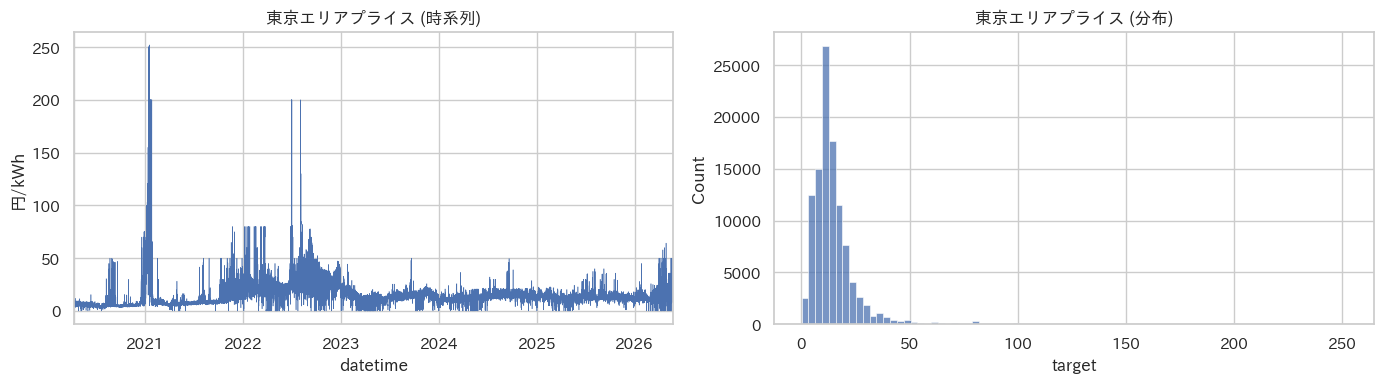

In [34]:
# ターゲット分布の確認
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
feature_df["target"].plot(ax=axes[0], lw=0.4)
axes[0].set_title("東京エリアプライス (時系列)")
axes[0].set_ylabel("円/kWh")
sns.histplot(feature_df["target"], bins=80, ax=axes[1])
axes[1].set_title("東京エリアプライス (分布)")
plt.tight_layout()
plt.show()


## 保存


In [35]:
feature_df.to_parquet(OUTPUT_PARQUET)

metadata = {
    "target": "target",
    "rows": int(len(feature_df)),
    "period": [str(feature_df.index.min()), str(feature_df.index.max())],
    "calendar_cols": cal_cols,
    "weather_cols": weather_cols,
    "tepco_cols": tepco_cols,
    "lag_cols": lag_cols,
    "target_alt_cols": TARGET_ALT_COLS,
    "trend_cols": TREND_COLS,
    "log1p_offset": LOG1P_OFFSET,
    "leak_policy": "day-ahead: features at date D use only data with date <= D-1 (TEPCO/weather actuals at t are treated as forecast-known proxies)",
}
FEATURE_META_JSON.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved :", OUTPUT_PARQUET)
print("meta  :", FEATURE_META_JSON)

reloaded = pd.read_parquet(OUTPUT_PARQUET)
print("reloaded shape:", reloaded.shape)
display(reloaded.head(3))


saved : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/jepx_tokyo_features.parquet
meta  : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/feature_metadata.json
reloaded shape: (107472, 38)


,target,hour,minute,dayofweek,month,day,is_weekend,is_holiday,is_dayoff,temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation,precipitation,tepco_demand,tepco_solar,tepco_wind,net_demand,pv_ratio,lag_1d_same_slot,lag_7d_same_slot,prev_day_mean,prev_day_max,prev_day_min,prev_day_std,prev_week_same_dow_mean,prev_week_same_dow_max,prev_week_same_dow_min,prev_week_same_dow_std,prev_day_band_peak,prev_day_band_early,target_log1p,target_arsinh,target_diff_1d,target_diff_7d,target_dev_prev_day,target_dev_prev_week,trend_30d_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-04-08 00:00:00,6.66,0,0,2,4,8,0,0,0,8.20,91.0,7.9,0.0,0.0,26120.0,0.0,50.0,26070.0,0.0,6.45,6.76,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333,2.158715,2.594856,0.21,-0.10,-0.64625,-1.927292,7.06997
2020-04-08 00:30:00,6.61,0,30,2,4,8,0,0,0,7.95,91.0,7.9,0.0,0.0,25555.0,0.0,55.0,25500.0,0.0,6.45,6.62,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333,2.152924,2.587404,0.16,-0.01,-0.69625,-1.977292,7.06997
2020-04-08 01:00:00,6.54,1,0,2,4,8,0,0,0,7.70,91.0,7.9,0.0,0.0,24990.0,0.0,60.0,24930.0,0.0,6.46,6.61,7.30625,9.02,6.31,1.066379,8.587292,11.64,6.5,1.385415,8.936667,6.563333,2.144761,2.576879,0.08,-0.07,-0.76625,-2.047292,7.06997
